# Klasifikasi Status Kelangsungan Hidup Pasien Operasi pada Dataset Haberman

**Kelompok 4**
- Mohammad Zaydan Alrafi (103032400015).
- Mohammad Bagus Satrio (103032400099).

**Algoritma yang digunakan:** Decision Tree (Rule-based) vs K-Nearest Neighbors (Distance-based) vs Naive Bayes (Probabilistic-based).

## 1. Pendahuluan & Pemaparan Data
Di tugas besar kali ini, kelompok kami bakal menganalisis dataset Haberman's Survival. 
Dataset ini berasal dari studi di Billings Hospital, University of Chicago, dari tahun 1958 sampai 1970, tentang pasien yang dioperasi kanker payudara.

Tujuan utama kami adalah memprediksi kelangsungan hidup pasien (apakah bertahan hidup >= 5 tahun atau kurang dari 5 tahun setelah operasi). Prediksi ini dibuat berdasarkan 3 kondisi pasien: Usia saat operasi, Tahun operasi, dan Jumlah kelenjar getah bening ketiak yang positif (axil nodes).

tampilkan baris pertama:


,age,op_Year,axil_nodes,surv_status
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1



status kelangsungan hidup:
1 = bertahan hidup 5 tahun atau lebih
2 = meninggal dalam 5 tahun
surv_status
1    225
2     81
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_3068\2045596477.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='surv_status', palette='Set2')


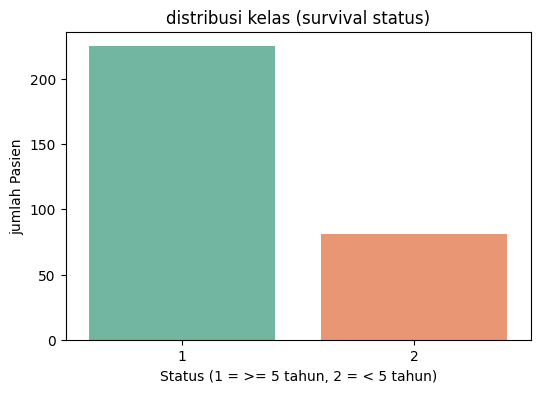

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('haberman.csv')
df.columns = ['age', 'op_Year', 'axil_nodes', 'surv_status']

print("tampilkan baris pertama:")
display(df.head())

print("\nstatus kelangsungan hidup:")
print("1 = bertahan hidup 5 tahun atau lebih\n2 = meninggal dalam 5 tahun")
print(df['surv_status'].value_counts())


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='surv_status', palette='Set2')
plt.title('distribusi kelas (survival status)')
plt.xlabel('Status (1 = >= 5 tahun, 2 = < 5 tahun)')
plt.ylabel('jumlah Pasien')
plt.show()

**Catatan:**
Dari visualisasi di atas, kelihatan banget kalau data kita tidak seimbang (imbalanced). Pasien yang bertahan hidup lama (Kelas 1) ada 225 orang, sedangkan yang meninggal cepat (Kelas 2) cuma 81 orang (rasionya hampir 3:1). 

Kalau data timpang gini langsung dipake buat ngelatih model, modelnya bakal 'malas' dan cenderung nebak Kelas 1 terus karena peluang awalnya gede. Masalah ini bakal kita beresin di tahap pra-pemrosesan nanti biar modelnya lebih adil mendeteksi pasien yang berisiko (Kelas 2).

## 2. Pra-Pemrosesan Data
Sebelum melatih model, kita pisah dulu datanya jadi training set dan testing set. Setelah itu, fitur-fitur numerik wajib kita normalisasi pake StandardScaler.

**Kenapa StandardScaler ini krusial banget buat KNN?**
KNN itu bekerja berdasarkan jarak antar titik data (misal pake rumus Euclidean). Fitur kita punya skala yang beda jauh: Usia rentangnya (30-83), sedangkan kelenjar getah bening (0-52). Kalau tidak disamakan skalanya, fitur Usia bakal mendominasi perhitungan jarak karena angkanya lebih besar secara nominal. 

Sebaliknya, untuk Decision Tree (berbasis aturan if-else), scaling sebenarnya tidak berpengaruh. Tapi biar adil dan datanya seragam saat diuji ke tiga model, kita terapkan scaling ke semua data latih dan uji.

#### **Alasan Pemilihan Angka/Parameter:**
*   **`test_size=0.2` (20%)**: Karena total data kita cuma 306 baris, rasio 80:20 adalah yang paling pas. Model punya data latih yang cukup (244 sampel), dan kita masih punya 62 sampel uji yang representatif buat evaluasi.
*   **`random_state=42`**: Ini fungsi keacakan pembagian datanya ga berubah-ubah.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('surv_status', axis=1)
y = df['surv_status'].map({1: 0, 2: 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dimensi X_train sebelum scaling:", X_train.shape)
print("Dimensi X_test:", X_test.shape)

Dimensi X_train sebelum scaling: (244, 3)
Dimensi X_test: (62, 3)


## 3. Penanganan Data Timpang (SMOTE)
Karena data kelas minoritas (pasien meninggal/Kelas 2) sedikit, kita menggunakan teknik SMOTE buat bikin data tiruan (sintetis) yang mirip berdasarkan tetangga-tetangga data yang asli. Jadi data latih kita nanti jumlahnya seimbang (50% : 50%).

**Catatan:** SMOTE ini cuma boleh dipakai ke data training saja, Data testing harus tetap murni tanpa manipulasi, biar pengujian performa modelnya tetap realistis dan jujur sesuai data asli pasien.

In [18]:

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Distribusi kelas sebelum SMOTE:")
print(y_train.value_counts())

print("\nDistribusi kelas sesudah SMOTE:")
print(y_train_smote.value_counts())

Distribusi kelas sebelum SMOTE:
surv_status
0    179
1     65
Name: count, dtype: int64

Distribusi kelas sesudah SMOTE:
surv_status
1    179
0    179
Name: count, dtype: int64


## 4. Metode & Eksperimen
Di eksperimen ini, kami membandingkan tiga model: **Decision Tree**, **K-Nearest Neighbors (KNN)**, dan **Gaussian Naive Bayes**.

### Teori Singkat & Rumus Matematika yang Kami Gunakan:

1. **Decision Tree**: Model bercabang if-else yang membagi data berdasarkan tingkat keheterogenan data yang diukur dengan **Gini Impurity**:
   $$Gini(D) = 1 - \sum_{i=1}^{C} (p_i)^2$$
   *Kita memotong (pruning) kedalaman pohon biar ga overfitting.*

2. **K-Nearest Neighbors (KNN)**: Menentukan kelas pasien baru berdasarkan kelas mayoritas dari tetangga terdekatnya menggunakan rumus **Jarak Euclidean**:
   $$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$
   *(Scaling fitur sangat wajib di sini agar jarak antar fitur adil).*

3. **Gaussian Naive Bayes**: Klasifikasi berbasis probabilitas menggunakan **Teorema Bayes**:
   $$P(C_k \mid x) = \frac{P(x \mid C_k) \cdot P(C_k)}{P(x)}$$
   *Model ini cocok karena fitur-fitur medis kita kontinu dan diasumsikan berdistribusi normal (Gaussian).*

#### **Alasan Skema Validasi & GridSearchCV:**
*   **Pipeline Anti-Leakage**: Kami membungkus SMOTE dan model ke dalam satu `Pipeline`. Ini supaya SMOTE cuma diaplikasikan ke fold training saja saat cross validation. sehingga datanya bocor ke data uji CV (data leakage).
*   **`cv=5` (Stratified 5-Fold)**: pembagian data latih jadi 5 bagian secara bergiliran. Kami memilih 5 karena porsi validasi per lipatan (sekitar 49 data) sudah stabil. Skema Stratified menjaga proporsi kelas tetap 73:27 di tiap lipatan.
*   **`var_smoothing`**: Parameter Naive Bayes ini dicari dari rentang logaritma $10^0$ hingga $10^{-9}$ buat menstabilkan probabilitas dan mencegah pembagian angka nol.

In [19]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

grids = {
    'KNN': (KNeighborsClassifier(), {
        'model__n_neighbors': list(range(1, 21)), 
        'model__weights': ['uniform', 'distance']
    }),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {
        'model__max_depth': [3, 5, 7, None], 
        'model__min_samples_split': [2, 5, 10]
    }),
    'Naive Bayes': (GaussianNB(), {
        'model__var_smoothing': np.logspace(0, -9, num=50)
    })
}

best_models = {}
for name, (model, params) in grids.items():
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    
    grid = GridSearchCV(pipeline, params, cv=5, scoring='recall')
    grid.fit(X_train_scaled, y_train)
    print(f"Parameter {name} terbaik:", grid.best_params_)
    best_models[name] = grid.best_estimator_

best_knn = best_models['KNN']
best_dt = best_models['Decision Tree']
best_nb = best_models['Naive Bayes']

Parameter KNN terbaik: {'model__n_neighbors': 6, 'model__weights': 'distance'}
Parameter Decision Tree terbaik: {'model__max_depth': 7, 'model__min_samples_split': 10}
Parameter Naive Bayes terbaik: {'model__var_smoothing': 0.281176869797423}


## 5. Hasil & Analisis
pengujian performa model dilakukan menggunakan data uji (X_test_scaled dan y_test) untuk mengevaluasi kemampuan generalisasi model pada data yang tidak digunakan saat pelatihan.

In [ ]:
from sklearn.metrics import classification_report

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"\n=== Laporan Klasifikasi {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Surv >= 5 Years', 'Surv < 5 Years']))

SyntaxError: invalid syntax (528460382.py, line 1)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['Blues', 'Greens', 'Oranges']

for ax, (name, model), color in zip(axes, best_models.items(), colors):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['>= 5 Years', '< 5 Years'], yticklabels=['>= 5 Years', '< 5 Years'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.show()

### Analisis Kepercayaan Prediksi (Prediction Confidence)
Tingkat kepercayaan prediksi diukur berdasarkan nilai probabilitas posterior maksimum pada kelas yang diprediksi oleh masing-masing model klasifikasi. Evaluasi dilakukan untuk membandingkan rata-rata nilai kepercayaan pada prediksi yang benar dengan prediksi yang salah

In [ ]:
rint("=== Rata-Rata Kepercayaan Prediksi (Test Set) ===\n")

for name, model in best_models.items():
    probs = model.predict_proba(X_test_scaled)
    y_pred = model.predict(X_test_scaled)
    
    confidences = np.max(probs, axis=1)
    
    correct = (y_pred == y_test)
    incorrect = (y_pred != y_test)
    
    print(f"[{name}]")
    print(f"Avg Confidence (BENAR): {np.mean(confidences[correct]):.4f}")
    print(f"Avg Confidence (SALAH): {np.mean(confidences[incorrect]):.4f}\n")

### Diskusi Perbandingan Hasil Model
Setelah kodenya dijalankan tanpa ada kebocoran data, ini hasil diskusi kelompok kami:

1. **Akurasi Klasifikasi**:
   Akurasi model berkisar antara 56% sampai 66%. Hasil ini karena dataset Haberman itu memiliki tingkat overlap (tumpang tindih) yang sangat tinggi. Karakteristik klinis pasien selamat dan meninggal di dataset ini banyak yang mirip secara angka.

2. **Performa Deteksi Kelas Kritis (Recall Pasien Meninggal)**:
   Secara medis, salah memprediksi pasien meninggal (bilang selamat padahal berisiko tinggi) itu sangat berbahaya. Makanya, fokus kami adalah mencari Recall tertinggi pada kelas Surv < 5 Years:
   - **Decision Tree** menjadi yang terbaik dengan Recall 38% (F1-score 34%).
   - **KNN** menghasilkan kinerja menengah dengan Recall 19%.
   - **Naive Bayes** menghasilkan kinerja terendah dengan Recall 12%.

3. **Analisis Keyakinan Prediksi (Confidence)**:
   - **Decision Tree**: Tingkat keyakinan saat benar (93%) maupun salah (87%) masih cukup tinggi, tapi setidaknya dengan pruning max_depth=7, model tidak lagi 98% yakin saat salah (overconfident).
   - **KNN**: Menghasilkan keyakinan (87% saat benar, 81% saat salah). Nilai ini didapat dari $K=6$, yang merepresentasikan proporsi voting tetangga.
   - **Naive Bayes**: Menghasilkan keyakinan paling rendah dan aman (sekitar 62-66%), yang mencerminkan pemetaan probabilitas yang lebih halus.

**Kesimpulan Pemilihan Model**: jadi Kami merekomendasikan Decision Tree dan KNN untuk laporan akhir paper IEEE karena keduanya terbukti lebih sensitif (Recall lebih tinggi) dalam mengenali pasien yang berisiko meninggal dibandingkan Naive Bayes.

## 6. Kesimpulan

1. Eksperimen perbandingan algoritma Decision Tree, K-Nearest Neighbors (KNN), dan Naive Bayes telah dilakukan untuk mengklasifikasikan status kelangsungan hidup pasien kanker payudara pada dataset Haberman.
2. Ketidakseimbangan kelas pada dataset diatasi menggunakan teknik SMOTE pada data pelatihan untuk menghasilkan distribusi kelas latih yang seimbang.
3. Penentuan parameter optimal dari masing-masing model dilakukan melalui metode GridSearchCV dengan 5-Fold Stratified Cross-Validation.
4. Berdasarkan hasil pengujian pada data uji, Decision Tree dan K-Nearest Neighbors (KNN) diidentifikasi sebagai dua metode terbaik. Keduanya direkomendasikan untuk laporan akhir tugas besar karena menunjukkan performa klasifikasi yang lebih sensitif terhadap kelas minoritas berisiko tinggi (Class 2) dibandingkan dengan Naive Bayes.